In [1]:
import os
import pandas as pd

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [3]:
os.listdir(path)

['Training', 'Testing']

In [4]:
train_path=path+'/Training'
os.listdir(train_path)

['pituitary', 'notumor', 'meningioma', 'glioma']

In [5]:
test_path=path+'/Testing'
os.listdir(test_path)

['pituitary', 'notumor', 'meningioma', 'glioma']

In [6]:
def create_dataframe(path):
  image=[]
  label=[]
  for folder in os.listdir(path):
    folder_path=os.path.join(path,folder)
    if os.path.isdir(folder_path):
      for file in os.listdir(folder_path):
        image.append(os.path.join(folder_path,file))
        label.append(folder)
  return pd.DataFrame({'image':image,'label':label})


In [7]:
train_df=create_dataframe(train_path)
test_df=create_dataframe(test_path)

In [8]:
print(len(train_df))

5600


In [9]:
train_df.head()

,image,label
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary


In [10]:
train_df['label'].value_counts()

,count
label,
pituitary,1400
notumor,1400
meningioma,1400
glioma,1400


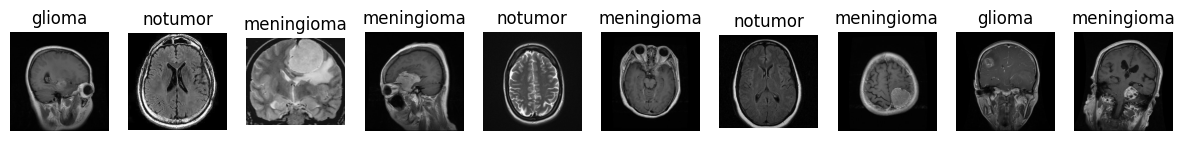

In [11]:
import matplotlib.pyplot as plt
import cv2

sample_df = train_df.sample(10)
plt.figure(figsize=(15, 5))

for i, row in enumerate(sample_df.itertuples()):
    plt.subplot(1, 10, i+1)
    img = cv2.imread(row.image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis('off')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
df_train,df_val=train_test_split(train_df,test_size=0.15,random_state=42,stratify=train_df['label'])

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [14]:
train_gen=ImageDataGenerator(rescale=1./255,horizontal_flip=True,zoom_range=0.1)
val_gen=ImageDataGenerator(rescale=1./255)

In [15]:
test_gen=ImageDataGenerator(rescale=1./255)

In [16]:
train_image=train_gen.flow_from_dataframe(train_df,x_col='image',y_col='label',target_size=(128,128),batch_size=32,class_mode='categorical')

Found 5600 validated image filenames belonging to 4 classes.


In [17]:
val_image=val_gen.flow_from_dataframe(df_val,x_col='image',y_col='label',target_size=(128,128),batch_size=32,class_mode='categorical')

Found 840 validated image filenames belonging to 4 classes.


In [18]:
test_image=train_gen.flow_from_dataframe(test_df,x_col='image',y_col='label',target_size=(128,128),batch_size=32,class_mode='categorical',shuffle=False)

Found 1600 validated image filenames belonging to 4 classes.


In [19]:
test_df.head()

,image,label
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary


In [20]:
from numpy.random import shuffle
test_gen = ImageDataGenerator(rescale=1./255)
test_image=test_gen.flow_from_dataframe(test_df,x_col='image',y_col='label',target_size=(128,128),batch_size=32,class_mode='categorical',shuffle=False)

Found 1600 validated image filenames belonging to 4 classes.


In [21]:
from tensorflow.keras import models,layers

In [22]:
model=models.Sequential()
model.add(layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',padding='valid',input_shape=(128, 128, 3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2,2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.add(layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu',padding='valid'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2,2)))

In [24]:
model.add(layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu',padding='valid'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2,2)))

In [25]:
model.add(layers.Flatten())
model.add(layers.Dense(units=128,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(units=4,activation='softmax'))

In [26]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,052 (12.61 MB)

 Trainable params: 3,305,604 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
history=model.fit(train_image,epochs=20,validation_data=val_image)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.5841 - loss: 1.4339 - val_accuracy: 0.2536 - val_loss: 3.9790
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.6446 - loss: 0.8384 - val_accuracy: 0.6179 - val_loss: 1.0077
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 294s 2s/step - accuracy: 0.6875 - loss: 0.7569 - val_accuracy: 0.8131 - val_loss: 0.5353
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.6982 - loss: 0.7096 - val_accuracy: 0.7952 - val_loss: 0.4674
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.7302 - loss: 0.6443 - val_accuracy: 0.7167 - val_loss: 0.8255
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.7487 - loss: 0.6043 - val_accuracy: 0.8393 - val_loss: 0.4606
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.7655 - loss: 0.5448 - val_accuracy: 0.8571 - val_loss: 0.3551
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - accuracy: 0.7768 - loss: 0.5141 - val_accu

In [28]:
val_loss = history.history['val_loss']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
train_acc = history.history['accuracy']

epochs = range(1,len(val_loss)+1)

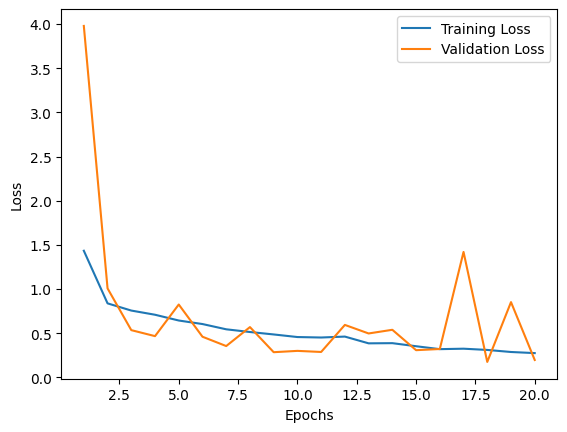

In [29]:
plt.plot(epochs,train_loss,label='Training Loss')
plt.plot(epochs,val_loss,label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

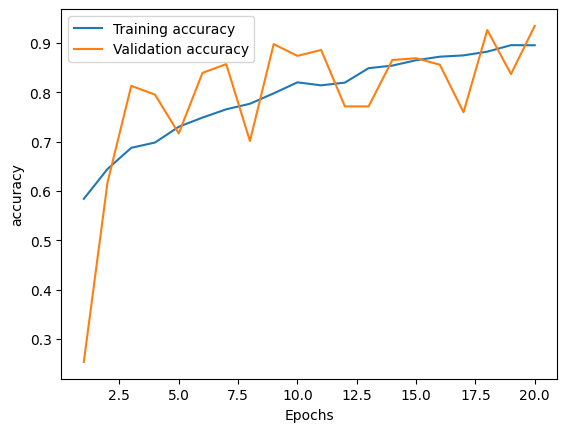

In [30]:
plt.plot(epochs,train_acc,label='Training accuracy')
plt.plot(epochs,val_acc,label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import classification_report,confusion_matrix

In [32]:
test_model=model.evaluate(test_image)

50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 390ms/step - accuracy: 0.8475 - loss: 1.1167


In [33]:
print(test_model)

[1.1167415380477905, 0.8475000262260437]


In [36]:
import numpy as np
y_pred=model.predict(test_image)
y_pred_classes=np.argmax(y_pred,axis=1)
y_true=test_image.classes
target_names = list(test_image.class_indices.keys())
print(classification_report(y_true, y_pred_classes, target_names=target_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 361ms/step
              precision    recall  f1-score   support

      glioma       0.92      0.73      0.81       400
  meningioma       0.84      0.70      0.76       400
     notumor       0.72      1.00      0.84       400
   pituitary       0.98      0.96      0.97       400

    accuracy                           0.85      1600
   macro avg       0.86      0.85      0.85      1600
weighted avg       0.86      0.85      0.85      1600



In [37]:
model.save('brain_tumor_model.h5')
print("Model Saved Successfully!")

Model Saved Successfully!
